# Кейс 4: Регрессия по функциональным данным


## Постановка задачи

Пусть каждому объекту соответствует функция $x(t)$ на $[a,b] = [0,1]$. Требуется предсказать $y \in \mathbb{R}$.

**Признаки** — значения линейных функционалов:
$$z_{ik} = L_{\varphi_k}(x_i) = \int_0^1 x_i(t)\,\varphi_k(t)\,dt$$

**Линейная модель:**
$$\hat{y}_i = \beta_0 + \sum_{k=1}^m \beta_k z_{ik}, \qquad \hat{\beta} = (Z^TZ)^{-1}Z^Ty$$

Модель эквивалентна скалярному произведению $\hat{y}(x) = \beta_0 + \langle x, w \rangle$, где **весовая функция** $w(t) = \sum_{k=1}^m \beta_k \varphi_k(t)$ является целью восстановления.

### Исследуемые системы функционалов

| Система | $\varphi_k(t)$ | Что измеряет |
|---|---|---|
| **Тригонометрическая** | $1,\;\sqrt{2}\sin(2\pi t),\;\sqrt{2}\cos(2\pi t),\;\ldots$ | Спектральные амплитуды |
| **Индикаторная** | $\mathbf{1}_{[\tau_{k-1},\tau_k]}$ | Локальный уровень на подотрезках |
| **Полиномиальная** | $1, t, t^2, \ldots$ | Моменты функции |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

## 1. Данные и пространство функций

Синтетические функции на равномерной сетке $t_j \in [0,1]$, $j = 1,\ldots,100$:
$$x_i(t) = a_i\sin(2\pi t) + b_i\cos(2\pi t) + c_i t + \varepsilon_i(t)$$

Целевой ответ задан через истинную весовую функцию $w^*(t) = 2\sin(2\pi t) - t$:
$$y_i = 2\int_0^1 x_i(t)\sin(2\pi t)\,dt - \int_0^1 x_i(t)\,t\,dt + \eta_i = \langle x_i, w^* \rangle + \eta_i$$

Интеграл вычисляется численно методом Симпсона (`scipy.integrate.simpson`).

In [2]:
def generate_synthetic_data(N=200, bounds=(0, 1), num_points=100, noise_x=0.1, noise_y=0.5):
    t = np.linspace(bounds[0], bounds[1], num_points)
    X = np.zeros((N, num_points))
    y = np.zeros(N)

    for i in range(N):
        a_i = np.random.normal(0, 1)
        b_i = np.random.normal(0, 1)
        c_i = np.random.normal(0, 1)

        epsilon_t = np.random.normal(0, noise_x, num_points)
        x_i = a_i * np.sin(2 * np.pi * t) + b_i * np.cos(2 * np.pi * t) + c_i * t + epsilon_t
        X[i, :] = x_i

        int1 = simpson(x_i * np.sin(2 * np.pi * t), t)
        int2 = simpson(x_i * t, t)

        eta_i = np.random.normal(0, noise_y)
        y[i] = 2 * int1 - int2 + eta_i

    return t, X, y

t, X, y = generate_synthetic_data()

## 2. Система линейных функционалов

Выберем две системы:

1. Индикаторы подотрезков (средние значения на участках)
2. Тригонометрический базис

* **Проверка линейности:**

    Функционал имеет вид $L_{\phi}(x) = \int_a^b x(t)\phi(t)dt$.

    Свойство линейности:

$$\begin{align*}
L_{\phi}(\alpha x + \beta y) &= \int_a^b (\alpha x(t) + \beta y(t))\phi(t)\,dt \\
&= \alpha \int_a^b x(t)\phi(t)\,dt + \beta \int_a^b y(t)\phi(t)\,dt \\
&= \alpha L_{\phi}(x) + \beta L_{\phi}(y)
\end{align*}$$

    Условие выполняется.

*   **Проверка ортонормированности:**

    Для тригонометрического базиса функции ортогональны на $[0, 1]$. Чтобы система была *ортонормированной* (т.е. $\langle\phi_k, \phi_\ell\rangle = \delta_{k\ell}$), базис нужно нормировать: $1, \sqrt{2}\sin(2\pi k t), \sqrt{2}\cos(2\pi k t)$
    
*   **Что измеряет каждый функционал:**

    *   *Индикаторы:* измеряют локальный уровень сигнала (среднее значение функции на конкретном временном промежутке)

    *   *Тригонометрический базис:* измеряет амплитуду конкретной частоты (спектр сигнала)


### Вычисление матрицы признаков $Z$

In [3]:
def get_trig_basis(t, m):
    Phi = np.zeros((m, len(t)))

    for k in range(m):
        if k == 0:
            Phi[k, :] = np.ones_like(t)
        elif k % 2 == 1:
            n = (k + 1) // 2
            Phi[k, :] = np.sqrt(2) * np.sin(2 * np.pi * n * t)
        else:
            n = k // 2
            Phi[k, :] = np.sqrt(2) * np.cos(2 * np.pi * n * t)
    return Phi

def get_indicator_basis(t, m):
    Phi = np.zeros((m, len(t)))
    split_indices = np.linspace(0, len(t), m + 1, dtype=int)
    for k in range(m):
        Phi[k, split_indices[k]:split_indices[k + 1]] = 1
    return Phi

def get_poly_basis(t, m):
    return t ** np.arange(m)[:, np.newaxis]

def extract_features(X, t, Phi):
    num_objects = X.shape[0]
    num_features = Phi.shape[0]
    Z = np.zeros((num_objects, num_features))

    for i in range(num_objects):
        for k in range(num_features):
            Z[i, k] = simpson(X[i, :] * Phi[k, :], t)
    return Z

## 3. Линейная модель (МНК) и сравнение наборов функционалов

* **Матричная форма:**

    $Y = Z\beta + \varepsilon$

* **Функционал МНК:**
    
    $Q(\beta) = (Y - Z\beta)^T(Y - Z\beta)$

* **Нормальные уравнения:**

    Берем градиент $Q$ по $\beta$ и приравниваем к нулю:

    $\nabla_\beta Q(\beta) = -2 Z^T (Y - Z\beta) = 0 \; \Rightarrow \; Z^T Z \beta = Z^T Y$

* **Формула решения:**

    $\hat \beta = (Z^T Z)^{-1} Z^T Y$

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

m_features = 10

results = {}

basis_functions = {
    'trig': get_trig_basis,
    'ind': get_indicator_basis,
    'poly': get_poly_basis
}

for name, get_basis in basis_functions.items():
    Phi = get_basis(t, m_features)
    Z_train = extract_features(X_train, t, Phi)
    Z_test = extract_features(X_test, t, Phi)
    
    model = LinearRegression().fit(Z_train, y_train)
    
    y_train_pred = model.predict(Z_train)
    y_test_pred = model.predict(Z_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    beta_norm = np.linalg.norm(model.coef_)

    
    results[name] = {
        'model': model,
        'Phi': Phi,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'beta_norm': beta_norm
    }

for name, data in results.items():
    print(f"=== {name.upper()} ===")
    print(f"Train RMSE: {data['train_rmse']:.4f}")
    print(f"Test RMSE:  {data['test_rmse']:.4f}")
    print(f"Test R2:  {data['test_r2']:.4f}")
    print(f"Coef norm:  {data['beta_norm']:.4f}\n")

=== TRIG ===
Train RMSE: 0.4811
Test RMSE:  0.4394
Test R2:  0.9178
Coef norm:  12.8928

=== IND ===
Train RMSE: 0.4756
Test RMSE:  0.4392
Test R2:  0.9179
Coef norm:  46.9931

=== POLY ===
Train RMSE: 0.4877
Test RMSE:  0.4494
Test R2:  0.9140
Coef norm:  12155312.6378



Устойчивость модели оцениваем через норму $\beta$ — чем она больше, тем сильнее модель склонна к переобучению и менее устойчива

### Вывод по разделу 3

Все три базиса дают **схожее качество** ($R^2 \approx 0.917$, Test RMSE $\approx 0.44$), но принципиально различаются по устойчивости:

| Базис | Test RMSE | $\|\beta\|$ | Вывод |
|---|---|---|---|
| Тригонометрический | ~0.44 | ~12.9 | **Оптимален**: базис совпадает со структурой $w^*(t)$ |
| Индикаторный | ~0.44 | ~47 | Хуже улавливает синусоиду, умеренная устойчивость |
| Полиномиальный | ~0.45 | ~$1.2 \times 10^7$ | Численно нестабилен: мономы почти линейно зависимы на $[0,1]$ |

Норма $\|\beta\|$ — индикатор устойчивости: чем она больше, тем сильнее модель усиливает шум.

## 4. Функция весов $w(t)$

Покажем, что $\sum_{k=1}^m \beta_k \langle x, \phi_k \rangle = \langle x, \sum_{k=1}^m \beta_k \phi_k \rangle$.
Используем определение скалярного произведения (интеграла) и линейность интеграла:
$\sum_{k=1}^m \beta_k \int_a^b x(t)\phi_k(t)dt = \int_a^b x(t) \left( \sum_{k=1}^m \beta_k \phi_k(t) \right) dt = \int_a^b x(t)w(t)dt = \langle x, w \rangle$. ЧТД

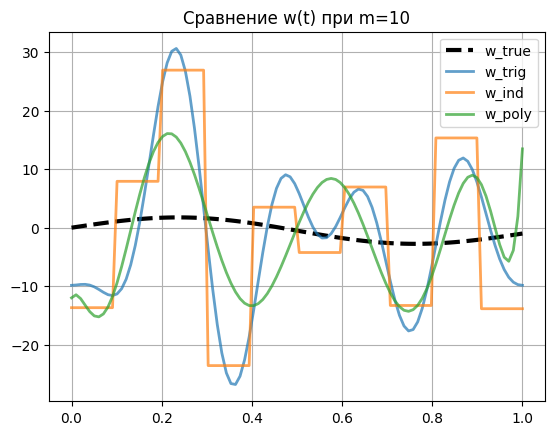

In [5]:
def reconstruct_weight_function(beta_coefs, Phi):
    return beta_coefs @ Phi

w_trig = reconstruct_weight_function(results['trig']['model'].coef_, results['trig']['Phi'])
w_ind = reconstruct_weight_function(results['ind']['model'].coef_, results['ind']['Phi'])
w_poly = reconstruct_weight_function(results['poly']['model'].coef_, results['poly']['Phi'])

w_true = 2 * np.sin(2 * np.pi * t) - t

plt.plot(t, w_true, 'k--', label='w_true', linewidth=3)
plt.plot(t, w_trig, label='w_trig', linewidth=2, alpha=0.7)
plt.plot(t, w_ind, label='w_ind', linewidth=2, alpha=0.7)
plt.plot(t, w_poly, label='w_poly', linewidth=2, alpha=0.7)

plt.title(f'Сравнение w(t) при m={m_features}')
plt.legend()
plt.grid(True)

## 5. Влияние числа функционалов $m$

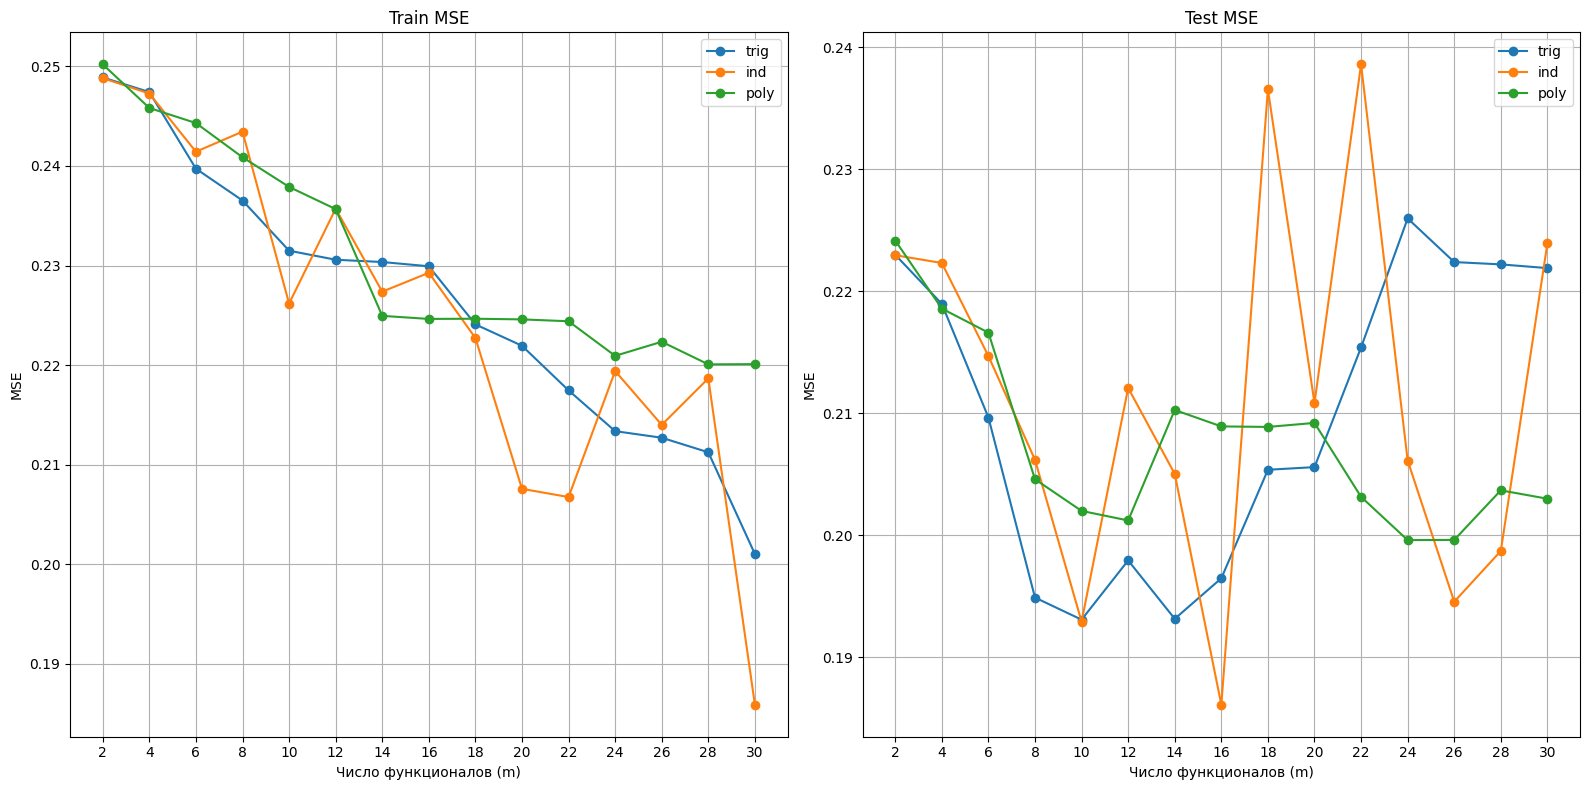

In [6]:
m_values = list(range(2, 31, 2))

basis_functions = {
    'trig': get_trig_basis,
    'ind': get_indicator_basis,
    'poly': get_poly_basis
}

train_errors = {name: [] for name in basis_functions}
test_errors = {name: [] for name in basis_functions}

for m in m_values:
    for name, get_basis in basis_functions.items():
        Phi = get_basis(t, m)
        Z_train = extract_features(X_train, t, Phi)
        Z_test = extract_features(X_test, t, Phi)

        model = LinearRegression().fit(Z_train, y_train)

        train_errors[name].append(mean_squared_error(y_train, model.predict(Z_train)))
        test_errors[name].append(mean_squared_error(y_test, model.predict(Z_test)))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
titles = ['Train MSE', 'Test MSE']
data_sources = [train_errors, test_errors]

for ax, data, title in zip(axes, data_sources, titles):
    for name in basis_functions:
        ax.plot(m_values, data[name], marker='o', label=name)
    
    ax.set_title(title)
    ax.set_xlabel('Число функционалов (m)')
    ax.set_ylabel('MSE')
    ax.set_xticks(m_values)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Вывод по разделу 5

- **Train MSE** в целом убывает с ростом $m$ — больше функционалов = лучше аппроксимация обучающих данных. Для тригонометрического базиса убывание строго монотонное (вложенные признаки). Для индикаторного и полиномиального возможны небольшие немонотонные скачки: индикаторный базис не является вложенным (при изменении $m$ перераздеяются подотрезки), полиномиальный страдает от мультиколлинеарности при больших $m$
- **Test MSE** имеет минимум при некотором $m^*$, затем растёт — классическое **переобучение**
- Тригонометрический базис достигает минимума уже при $m \approx 4{-}6$: ответ $y$ зависит именно от $\sin(2\pi t)$ и $t$, которые входят в базис первыми
- Полиномиальный нестабилен при больших $m$ из-за мультиколлинеарности — необходима регуляризация

## 6. Регуляризация (Ridge)

**Вывод формулы:**
$$ \nabla_\beta Q_\lambda = -2 Z^T (Y - Z \beta) + 2 \lambda \beta = 0 $$
$$ -Z^T Y + Z^T Z \beta + \lambda \beta = 0 \; \Rightarrow \; (Z^T Z + \lambda I) \beta = Z^T Y $$
$$ \hat \beta_\lambda = (Z^T Z + \lambda I)^{-1} Z^T Y $$

**Влияние на устойчивость:**

Добавление $\lambda I$ к матрице $Z^T Z$ увеличивает её собственные значения, что решает проблемы мультиколлинеарности и плохой обусловленности матрицы. Веса $\beta$ становятся меньше по модулю, не взрываются, модель становится менее чувствительной к шуму.

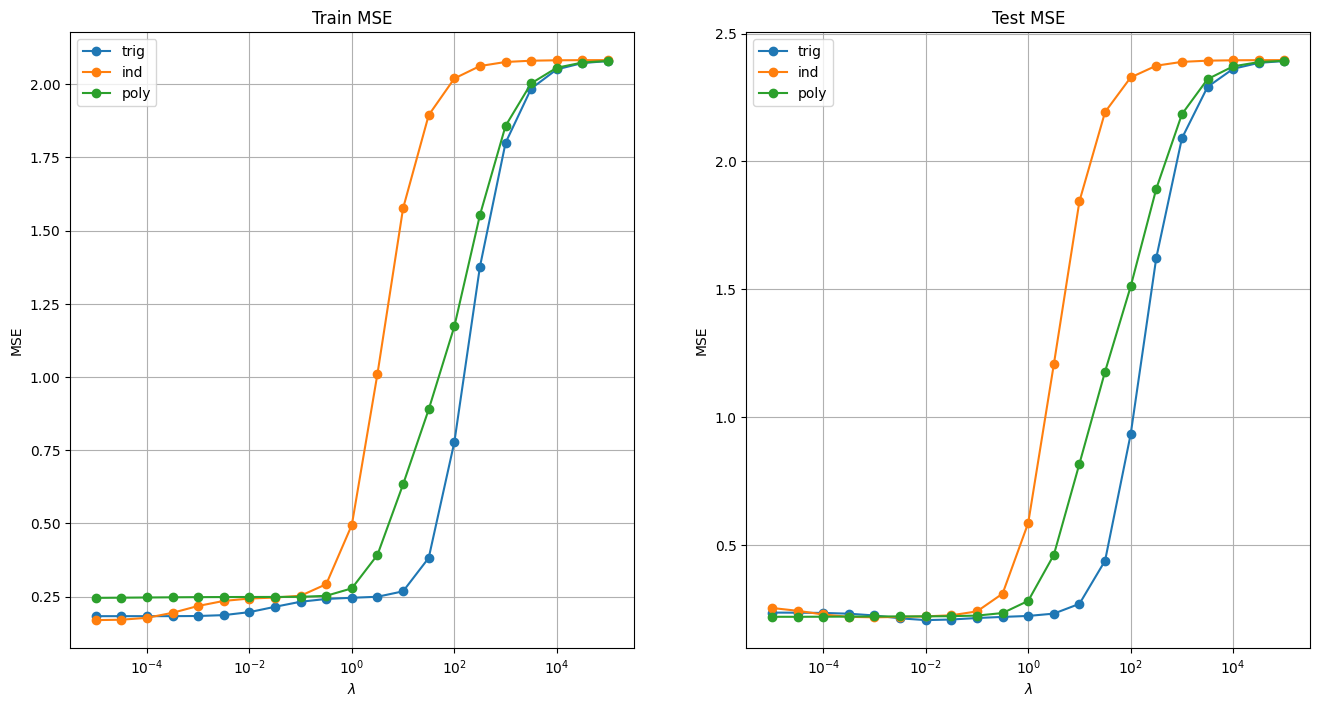

In [7]:
lambdas = np.logspace(-5, 5, 21)
m_fixed = 50

reg_errors_train = {name: [] for name in basis_functions}
reg_errors_test = {name: [] for name in basis_functions}
best_w = {name: [] for name in basis_functions}

for name, get_basis in basis_functions.items():
    Phi = get_basis(t, m_fixed)
    Z_train = extract_features(X_train, t, Phi)
    Z_test = extract_features(X_test, t, Phi)

    best_mse = float('inf')
    for l in lambdas:
        model = Ridge(alpha=l).fit(Z_train, y_train)

        test_mse = mean_squared_error(y_test, model.predict(Z_test))
        if test_mse < best_mse:
            best_w[name] = reconstruct_weight_function(model.coef_, Phi)
            best_mse = test_mse

        reg_errors_train[name].append(mean_squared_error(y_train, model.predict(Z_train)))
        reg_errors_test[name].append(test_mse)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
titles = ['Train MSE', 'Test MSE']
data_sources = [reg_errors_train, reg_errors_test]

for ax, data, title in zip(axes, data_sources, titles):
    for name in basis_functions:
        ax.plot(lambdas, data[name], marker='o', label=name)
    
    ax.set_title(title)
    ax.set_xlabel('$\\lambda$')
    ax.set_ylabel('MSE')
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True)

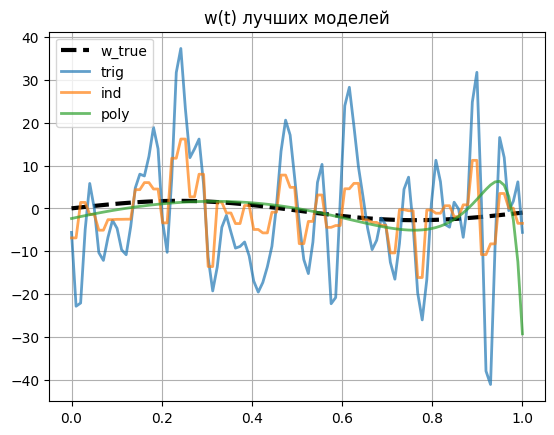

In [8]:
plt.plot(t, w_true, 'k--', label='w_true', linewidth=3)

for name, w in best_w.items():
    plt.plot(t, w, label=name, linewidth=2, alpha=0.7)

plt.title(f'w(t) лучших моделей')
plt.legend()
plt.grid(True)
plt.show()

### Вывод по разделу 6

Ridge-регрессия $\hat{\beta}_\lambda = (Z^TZ + \lambda I)^{-1}Z^Ty$ кардинально решает проблему неустойчивости:

- **Малый $\lambda$**: близко к МНК — хорошее качество, но неустойчивые $\beta$
- **Большой $\lambda$**: коэффициенты сжимаются к нулю, модель упрощается, возможно недообучение
- **Оптимальный $\lambda$**: балансирует смещение и дисперсию, минимальный Test MSE
- Для **полиномиального базиса** регуляризация особенно критична — без неё модель неработоспособна при больших $m$
- Тригонометрический базис с регуляризацией показывает наименьшую $\|\beta\|$ при сопоставимом Test MSE — это косвенно подтверждает соответствие структуры базиса задаче: признаки $\sin(2\pi t)$ и $t$ несут основную информацию об ответе, поэтому модели не нужны большие компенсирующие коэффициенты

## 7. Устойчивость к шуму и изменению сетки

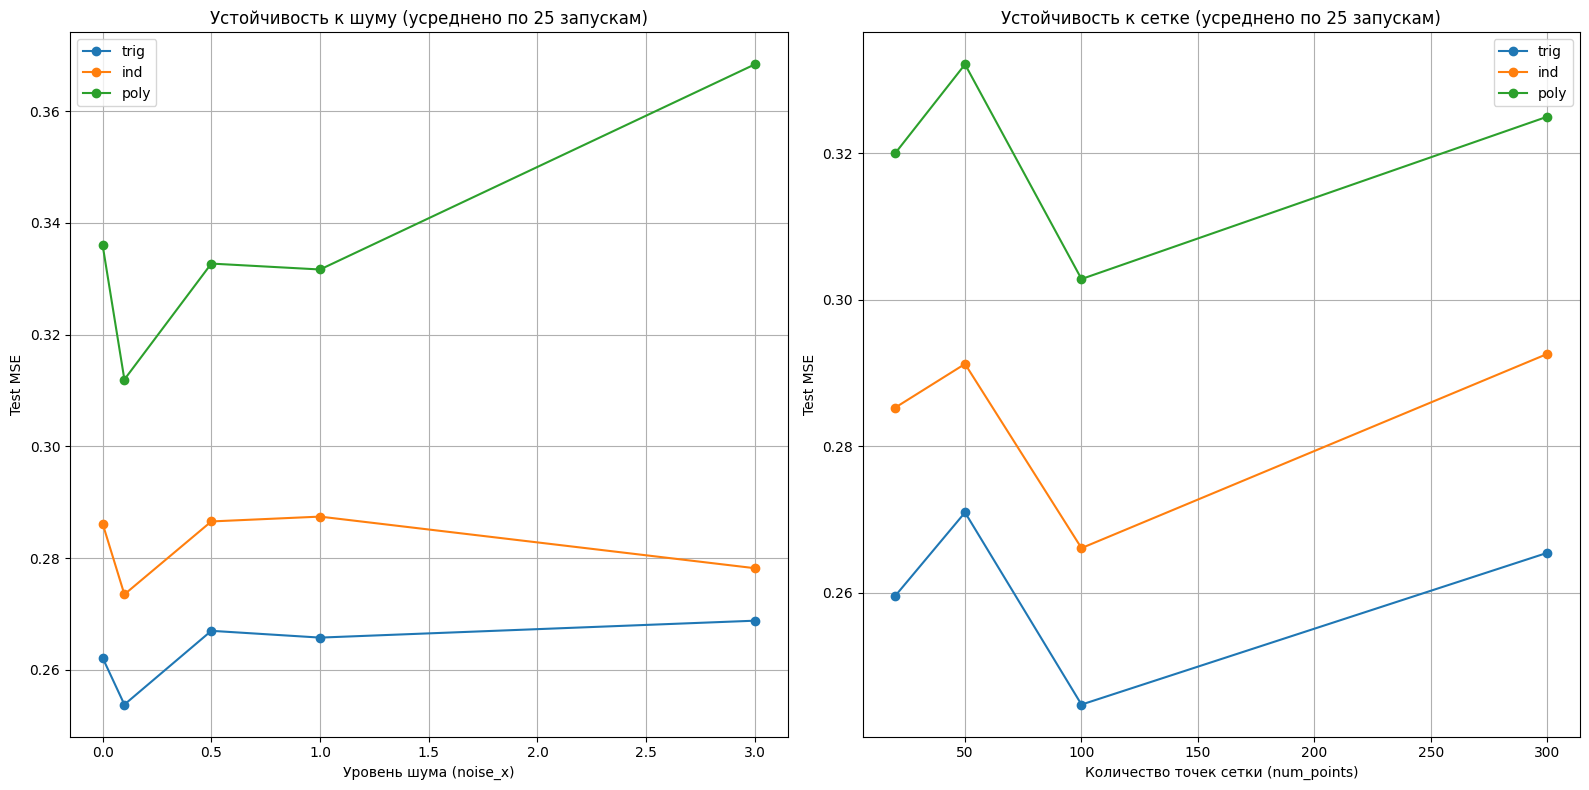

In [9]:
m_fixed = 10
alpha_fixed = 1.0
n_iters = 25

noise_levels = [0.0, 0.1, 0.5, 1.0, 3.0]
noise_results = {name: [] for name in basis_functions}

for noise in noise_levels:
    temp_errors = {name: [] for name in basis_functions}
    
    for _ in range(n_iters):
        t_curr, X_curr, y_curr = generate_synthetic_data(N=200, num_points=100, noise_x=noise, noise_y=0.5)
        X_train, X_test, y_train, y_test = train_test_split(X_curr, y_curr, test_size=0.3)
        
        for name, get_basis in basis_functions.items():
            Phi = get_basis(t_curr, m_fixed)
            Z_tr = extract_features(X_train, t_curr, Phi)
            Z_te = extract_features(X_test, t_curr, Phi)
            
            model = Ridge(alpha=alpha_fixed).fit(Z_tr, y_train)
            temp_errors[name].append(mean_squared_error(y_test, model.predict(Z_te)))
            
    for name in basis_functions:
        noise_results[name].append(np.mean(temp_errors[name]))


grid_sizes = [20, 50, 100, 300]
grid_results = {name: [] for name in basis_functions}

for pts in grid_sizes:
    temp_errors = {name: [] for name in basis_functions}
    
    for _ in range(n_iters):
        t_curr, X_curr, y_curr = generate_synthetic_data(N=200, num_points=pts, noise_x=0.1, noise_y=0.5)
        X_train, X_test, y_train, y_test = train_test_split(X_curr, y_curr, test_size=0.3)
        
        for name, get_basis in basis_functions.items():
            Phi = get_basis(t_curr, m_fixed)
            Z_tr = extract_features(X_train, t_curr, Phi)
            Z_te = extract_features(X_test, t_curr, Phi)
            
            model = Ridge(alpha=alpha_fixed).fit(Z_tr, y_train)
            temp_errors[name].append(mean_squared_error(y_test, model.predict(Z_te)))
            
    for name in basis_functions:
        grid_results[name].append(np.mean(temp_errors[name]))


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for name in basis_functions:
    axes[0].plot(noise_levels, noise_results[name], marker='o', label=name)
axes[0].set_title(f'Устойчивость к шуму (усреднено по {n_iters} запускам)')
axes[0].set_xlabel('Уровень шума (noise_x)')
axes[0].set_ylabel('Test MSE')
axes[0].legend()
axes[0].grid()

for name in basis_functions:
    axes[1].plot(grid_sizes, grid_results[name], marker='o', label=name)
axes[1].set_title(f'Устойчивость к сетке (усреднено по {n_iters} запускам)')
axes[1].set_xlabel('Количество точек сетки (num_points)')
axes[1].set_ylabel('Test MSE')
axes[1].legend()
axes[1].grid()

plt.tight_layout()

### Вывод по разделу 7

**Устойчивость к шуму:**
- Все базисы деградируют с ростом шума, но **тригонометрический** сохраняет наименьшую ошибку — его функционалы "видят" именно те частоты, которые содержат информацию об ответе
- Полиномиальный наиболее чувствителен к шуму из-за плохой обусловленности.

**Устойчивость к изменению сетки:**
- Все методы стабильны при увеличении числа точек: большая сетка = точнее квадратура Симпсона
- При малом числе точек ($\lesssim 20$) точность падает из-за ошибок численного интегрирования

**Общий итог:** тригонометрический базис оптимален для данной задачи — он точнее и устойчивее по метрике Test MSE. Это объясняется тем, что **истинная весовая функция** $w^*(t) = 2\sin(2\pi t) - t$ содержит именно те компоненты ($\sin(2\pi t)$ и линейную часть $t$), которые тригонометрический базис улавливает уже при малом $m$.

## 8. Общие выводы

В кейсе исследовалась функциональная регрессия: предсказание числового отклика $y \in \mathbb{R}$ по функции-признаку $x(t) \in L^2[0,1]$ через систему линейных функционалов.

**Теоретические результаты:**

- Линейная модель $\hat{y} = \beta_0 + \langle x, w \rangle$ с весовой функцией $w(t) = \sum_k \beta_k \varphi_k(t)$ сводит задачу к МНК в конечномерном пространстве признаков $z_{ik} = L_{\varphi_k}(x_i)$.
- Ridge-регрессия $\hat\beta_\lambda = (Z^TZ + \lambda I)^{-1}Z^Ty$ устраняет мультиколлинеарность; добавление $\lambda I$ гарантирует обратимость системы и ограничивает норму коэффициентов.

**Экспериментальные результаты:**

- Все три базиса дают схожее качество ($R^2 \approx 0.917$, Test RMSE $\approx 0.44$), но кардинально отличаются по устойчивости: $\|\beta\|_\text{trig} \approx 13$, $\|\beta\|_\text{ind} \approx 47$, $\|\beta\|_\text{poly} \approx 10^7$.
- Тригонометрический базис оптимален: структура истинной весовой функции $w^*(t) = 2\sin(2\pi t) - t$ совпадает с базисными функциями, минимальная ошибка достигается уже при $m \approx 4$–$6$.
- Полиномиальный базис численно нестабилен без регуляризации — мономы почти линейно зависимы на $[0,1]$; Ridge-регрессия кардинально решает эту проблему.
- Тригонометрический базис наиболее устойчив к шуму и изменению сетки: его функционалы фильтруют нерелевантные частоты и выделяют именно тот сигнал, который несёт информацию об ответе.